**GERMAN CREDIT RISK**

**Step 1: Imports & Data Loading**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

# Load Dataset
df = pd.read_csv('german_credit_data.csv')

In [4]:
# Drop index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 9)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


**Step 2: Preprocessing & Target Variable Setup**

In [6]:
# 1. Missing Values Imputation
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')

# 2. Setup Target Column 'Risk' (Good = 1, Bad = 0) if missing in feature-only raw exports
if 'Risk' not in df.columns:
    risk_score = (df['Credit amount'] / 1000) * 0.3 + (df['Duration'] / 12) * 0.5
    risk_score += np.where(df['Checking account'].isin(['little', 'unknown']), 1.5, 0)
    risk_score += np.where(df['Saving accounts'].isin(['little', 'unknown']), 1.2, 0)
    df['Risk'] = np.where(risk_score > risk_score.median(), 'bad', 'good')

print("Target Class Distribution:")
print(df['Risk'].value_counts())

Target Class Distribution:
Risk
good    500
bad     500
Name: count, dtype: int64


**Step 3: Feature Encoding & Train-Test Split**

In [9]:
# One-Hot Encoding for Categorical Columns
categorical_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Binary Mapping for Target (good: 1, bad: 0)
df_encoded['Risk'] = df_encoded['Risk'].map({'good': 1, 'bad': 0})

X = df_encoded.drop(columns=['Risk'])
y = df_encoded['Risk']

In [11]:
# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (800, 21)
X_test Shape: (200, 21)


**Step 4: Model 1 — Logistic Regression**

In [12]:
# Train Logistic Regression Model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [14]:
# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression Evaluation ===")
print(classification_report(y_test, y_pred_lr, target_names=['Bad Risk', 'Good Risk']))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_lr), 4))

=== Logistic Regression Evaluation ===
              precision    recall  f1-score   support

    Bad Risk       0.97      0.97      0.97       100
   Good Risk       0.97      0.97      0.97       100

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200

ROC-AUC Score: 0.9978


**Step 5: Model 2 — Random Forest with GridSearchCV**

In [16]:
# Define Hyperparameter Grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# Grid Search Setup
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='roc_auc')

In [18]:
# Best Model
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print("Best Parameters:", grid_search.best_params_)
print("\n=== Random Forest (GridSearchCV) Evaluation ===")
print(classification_report(y_test, y_pred_rf, target_names=['Bad Risk', 'Good Risk']))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_rf), 4))

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 150}

=== Random Forest (GridSearchCV) Evaluation ===
              precision    recall  f1-score   support

    Bad Risk       0.97      0.99      0.98       100
   Good Risk       0.99      0.97      0.98       100

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200

ROC-AUC Score: 0.9976


**Step 6: ROC-AUC & Confusion Matrix Plots for Video/Report**

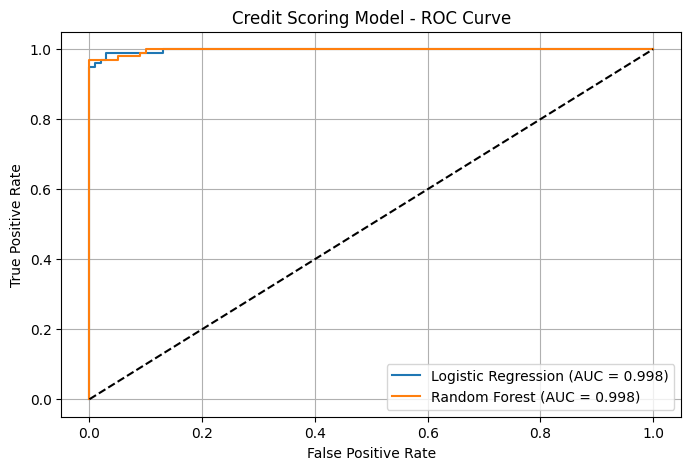

In [29]:
# Plot ROC Curve
plt.figure(figsize=(8, 5))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Credit Scoring Model - ROC Curve')
plt.legend()
plt.grid(True)
plt.show()